# Validating a General-Relativistic Ray Tracer Against Event Horizon Telescope Observations

**Ethan Knox** &nbsp;|&nbsp; [github.com/ethank5149](https://github.com/ethank5149) &nbsp;|&nbsp; ethank5149@gmail.com

---

## 1. Introduction

In April 2019, the Event Horizon Telescope (EHT) Collaboration published the first image of a black hole — M87\*, the supermassive object at the center of Messier 87 — revealing a bright asymmetric ring of diameter $42 \pm 3\;\mu\text{as}$ consistent with the predicted shadow of a Kerr black hole. In May 2022, the EHT released a second image: Sgr A\*, the $4 \times 10^6\;M_\odot$ black hole at the center of our Milky Way, with a shadow angular diameter of $48.7 \pm 7\;\mu\text{as}$.

In this notebook, I validate **[Nulltracer](https://github.com/ethank5149/nulltracer)** — a GPU-accelerated ray tracer I built — against these published EHT measurements. The CUDA kernel embedded below implements the Fuerst & Wu (2004) Hamiltonian formulation of null geodesics in the Kerr metric, cross-verified against the Odyssey (Pu et al. 2016), GRay (Chan et al. 2013), and RAPTOR (Bronzwaer et al. 2018) GPU ray-tracing codes, and validated against the analytic shadow boundary curve of Bardeen (1973).

---

## 2. Physics: The Kerr Metric and Null Geodesics

### 2.1 The Kerr Metric

A rotating black hole of mass $M$ and angular momentum $J = aM$ is described by the Kerr metric in Boyer-Lindquist coordinates $(t, r, \theta, \phi)$. In geometric units $G = c = M = 1$, with $\Sigma = r^2 + a^2\cos^2\theta$ and $\Delta = r^2 - 2r + a^2$:

$$ds^2 = -\frac{\Delta - a^2\sin^2\theta}{\Sigma}\,dt^2 - \frac{4ar\sin^2\theta}{\Sigma}\,dt\,d\phi + \frac{\Sigma}{\Delta}\,dr^2 + \Sigma\,d\theta^2 + \frac{A\sin^2\theta}{\Sigma}\,d\phi^2$$

where $A = (r^2 + a^2)^2 - a^2\Delta\sin^2\theta$. The event horizon is at $r_+ = 1 + \sqrt{1 - a^2}$.

### 2.2 Carter Separation and Constants of Motion

Carter (1968) showed that the Hamilton-Jacobi equation separates in the Kerr metric, yielding three constants of motion for null geodesics: energy $E = -p_t$, axial angular momentum $L_z = p_\phi$, and the Carter constant $\mathcal{Q} = p_\theta^2 + \cos^2\theta(a^2 E^2 - L_z^2/\sin^2\theta)$. Setting $E = 1$ (absorbing the energy into the affine parameter), define dimensionless impact parameters $\xi = L_z$ and $\eta = \mathcal{Q}$.

The separated radial and angular potentials are:

$$R(r) = r^4 + (a^2 - \xi^2 - \eta)\,r^2 + 2\bigl[(\xi - a)^2 + \eta\bigr]\,r - a^2\eta$$

$$\Theta(\theta) = \eta + a^2\cos^2\theta - \xi^2\cot^2\theta$$

### 2.3 Hamiltonian Equations of Motion

Following Fuerst & Wu (2004) and the Odyssey GPU code (Pu et al. 2016), the state vector is $(r, \theta, \phi, p_r, p_\theta)$ — five ODEs, since $p_t = -1$ and $p_\phi = \xi$ are constants. Define $\kappa = \eta + \xi^2 + a^2$.

| Equation | Explicit form |
|---|---|
| $\dot{r}$ | $\Delta\, p_r / \Sigma$ |
| $\dot{\theta}$ | $p_\theta / \Sigma$ |
| $\dot{\phi}$ | $\bigl[2ar + (\Sigma - 2r)\,\xi / \sin^2\theta\bigr] / (\Sigma\Delta)$ |
| $\dot{p}_r$ | $\bigl[-\kappa(r-1) + 2r(r^2+a^2) - 2a\xi\bigr] / (\Sigma\Delta) - 2p_r^2(r-1)/\Sigma$ |
| $\dot{p}_\theta$ | $\sin\theta\cos\theta\bigl[\xi^2/\sin^4\theta - a^2\bigr] / \Sigma$ |

At turning points ($R(r) = 0$ or $\Theta(\theta) = 0$), the momenta $p_r$ and $p_\theta$ pass smoothly through zero — no sign-tracking is needed, eliminating branch divergence on the GPU.

### 2.4 Impact Parameters (Bardeen 1973)

For a pixel at screen coordinates $(\alpha, \beta)$ in units of $M$, the conserved quantities are:

$$\xi = -\alpha\sin\theta_{\text{obs}}, \qquad \eta = \beta^2 + (\alpha^2 - a^2)\cos^2\theta_{\text{obs}}$$

The initial radial momentum is $p_r = -\sqrt{R(r_{\text{obs}})} / \Delta_{\text{obs}}$ (negative for backward/inward tracing), and $p_\theta = \beta$ (sign matches the polar direction of the arriving photon).

---

## 3. Implementation

### 3.1 Setup

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy.ndimage as ndi
import time

from nulltracer_kernels import (
    compile_all, render_kerr, compare_integrators, METHODS, auto_steps
)

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (10, 8), 'font.size': 12, 'font.family': 'serif',
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'savefig.dpi': 150, 'savefig.facecolor': 'black',
})

props = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = props['name'].decode() if isinstance(props['name'], bytes) else props['name']
print(f"GPU: {gpu_name} ({props['totalGlobalMem'] / 1e9:.1f} GB)")

GPU: NVIDIA GeForce RTX 3090 (25.3 GB)


### 3.2 ISCO (Bardeen, Press & Teukolsky 1972)

In [2]:
def r_plus(a):
    """Event horizon radius for a Kerr black hole."""
    return 1.0 + np.sqrt(max(1.0 - a * a, 0.0))

def isco_kerr(a):
    """Prograde ISCO radius (Bardeen, Press & Teukolsky 1972)."""
    z1 = 1.0 + (1.0 - a**2)**(1/3) * ((1.0 + a)**(1/3) + max(1.0 - a, 0.0)**(1/3))
    z2 = np.sqrt(3.0 * a**2 + z1**2)
    return 3.0 + z2 - np.sqrt((3.0 - z1) * (3.0 + z1 + 2.0 * z2))

print(f"ISCO (a=0):     {isco_kerr(0.0):.4f} M  (expected 6.0000)")
print(f"ISCO (a=0.998): {isco_kerr(0.998):.4f} M  (expected ~1.237)")

ISCO (a=0):     6.0000 M  (expected 6.0000)
ISCO (a=0.998): 1.2370 M  (expected ~1.237)


### 3.3 Analytic Shadow Boundary (Bardeen 1973, Chandrasekhar 1983)

The shadow edge corresponds to photons on unstable spherical orbits satisfying $R(r) = 0$ and $dR/dr = 0$. The critical impact parameters as functions of the orbit radius $r$ are:

$$\xi_c(r) = -\frac{r^3 - 3r^2 + a^2 r + a^2}{a(r - 1)}, \qquad \eta_c(r) = -\frac{r^3(r^3 - 6r^2 + 9r - 4a^2)}{a^2(r-1)^2}$$

Photon orbit radii range from $r_{\text{ph}}^- = 2[1 + \cos(\tfrac{2}{3}\arccos(-a))]$ (prograde) to $r_{\text{ph}}^+ = 2[1 + \cos(\tfrac{2}{3}\arccos(+a))]$ (retrograde).

In [3]:
def shadow_boundary(a, theta_obs, N=1000):
    """
    Compute the analytic Kerr shadow boundary on the observer's screen.
    Returns arrays (alpha, beta_plus, beta_minus) in units of M.
    """
    # For Schwarzschild, the shadow is a circle of radius 3√3
    if abs(a) < 1e-4:
        phi = np.linspace(0, 2 * np.pi, N)
        R = 3.0 * np.sqrt(3.0)
        return R * np.cos(phi), R * np.sin(phi), -R * np.sin(phi)

    r_min = 2 * (1 + np.cos(2/3 * np.arccos(-a)))
    r_max = 2 * (1 + np.cos(2/3 * np.arccos(+a)))
    r_arr = np.linspace(r_min + 1e-6, r_max - 1e-6, N)

    xi_c = -(r_arr**3 - 3*r_arr**2 + a**2*r_arr + a**2) / (a * (r_arr - 1) + 1e-30)
    eta_c = -r_arr**3 * (r_arr**3 - 6*r_arr**2 + 9*r_arr - 4*a**2) / (a**2 * (r_arr - 1)**2 + 1e-30)

    sobs = np.sin(theta_obs)
    cobs = np.cos(theta_obs)

    alpha = -xi_c / sobs
    disc = eta_c + a**2 * cobs**2 - xi_c**2 * cobs**2 / sobs**2
    disc = np.maximum(disc, 0)
    beta = np.sqrt(disc)

    return alpha, beta, -beta


# Schwarzschild check: shadow should be a circle of radius 3√3 ≈ 5.196 M
alpha_sch, beta_sch_p, beta_sch_m = shadow_boundary(1e-6, np.pi/2)
r_shadow_sch = np.sqrt(alpha_sch**2 + beta_sch_p**2).max()
print(f"Schwarzschild shadow radius: {r_shadow_sch:.4f} M (expected {3*np.sqrt(3):.4f})")

Schwarzschild shadow radius: 5.1962 M (expected 5.1962)


### 3.4 CUDA Ray-Tracing Kernel

The kernel below implements the exact Fuerst & Wu (2004) Hamiltonian ODEs from §2.3 with RK4 integration. Each GPU thread traces one null geodesic backward from the camera. All computations use `float64` for accuracy.

**Equation sources (line-by-line):**
- Impact parameters: Bardeen (1973), §4 of reference
- Initial $p_r$: §5 of reference, with $R(r)$ from §2
- RHS ODEs: Fuerst & Wu (2004), Odyssey (Pu et al. 2016, Eq. 14)
- Disk redshift: §9 of reference, $g = \sqrt{1 - 3/r + 2a/r^{3/2}} / (1 - \Omega\xi_\gamma)$

In [4]:
kernels = compile_all()
print("CUDA kernels compiled successfully.")

  Compiled: Runge-Kutta 4th-order (rk4)
  Compiled: Dormand-Prince 8(7) adaptive (rkdp8)
  Compiled: Tao + Yoshida 4th symplectic (tao_yoshida4)
  Compiled: Tao + Kahan-Li 8th symplectic (tao_kl8)
All 4 integrators ready.
CUDA kernels compiled successfully.


### 3.5 Rendering Function

---

## 4. Validation: Analytic Shadow Boundary

The most rigorous test: overlay the numerically ray-traced shadow boundary against the exact Bardeen (1973) analytic curve. Agreement to sub-pixel precision validates the entire geodesic integration pipeline.

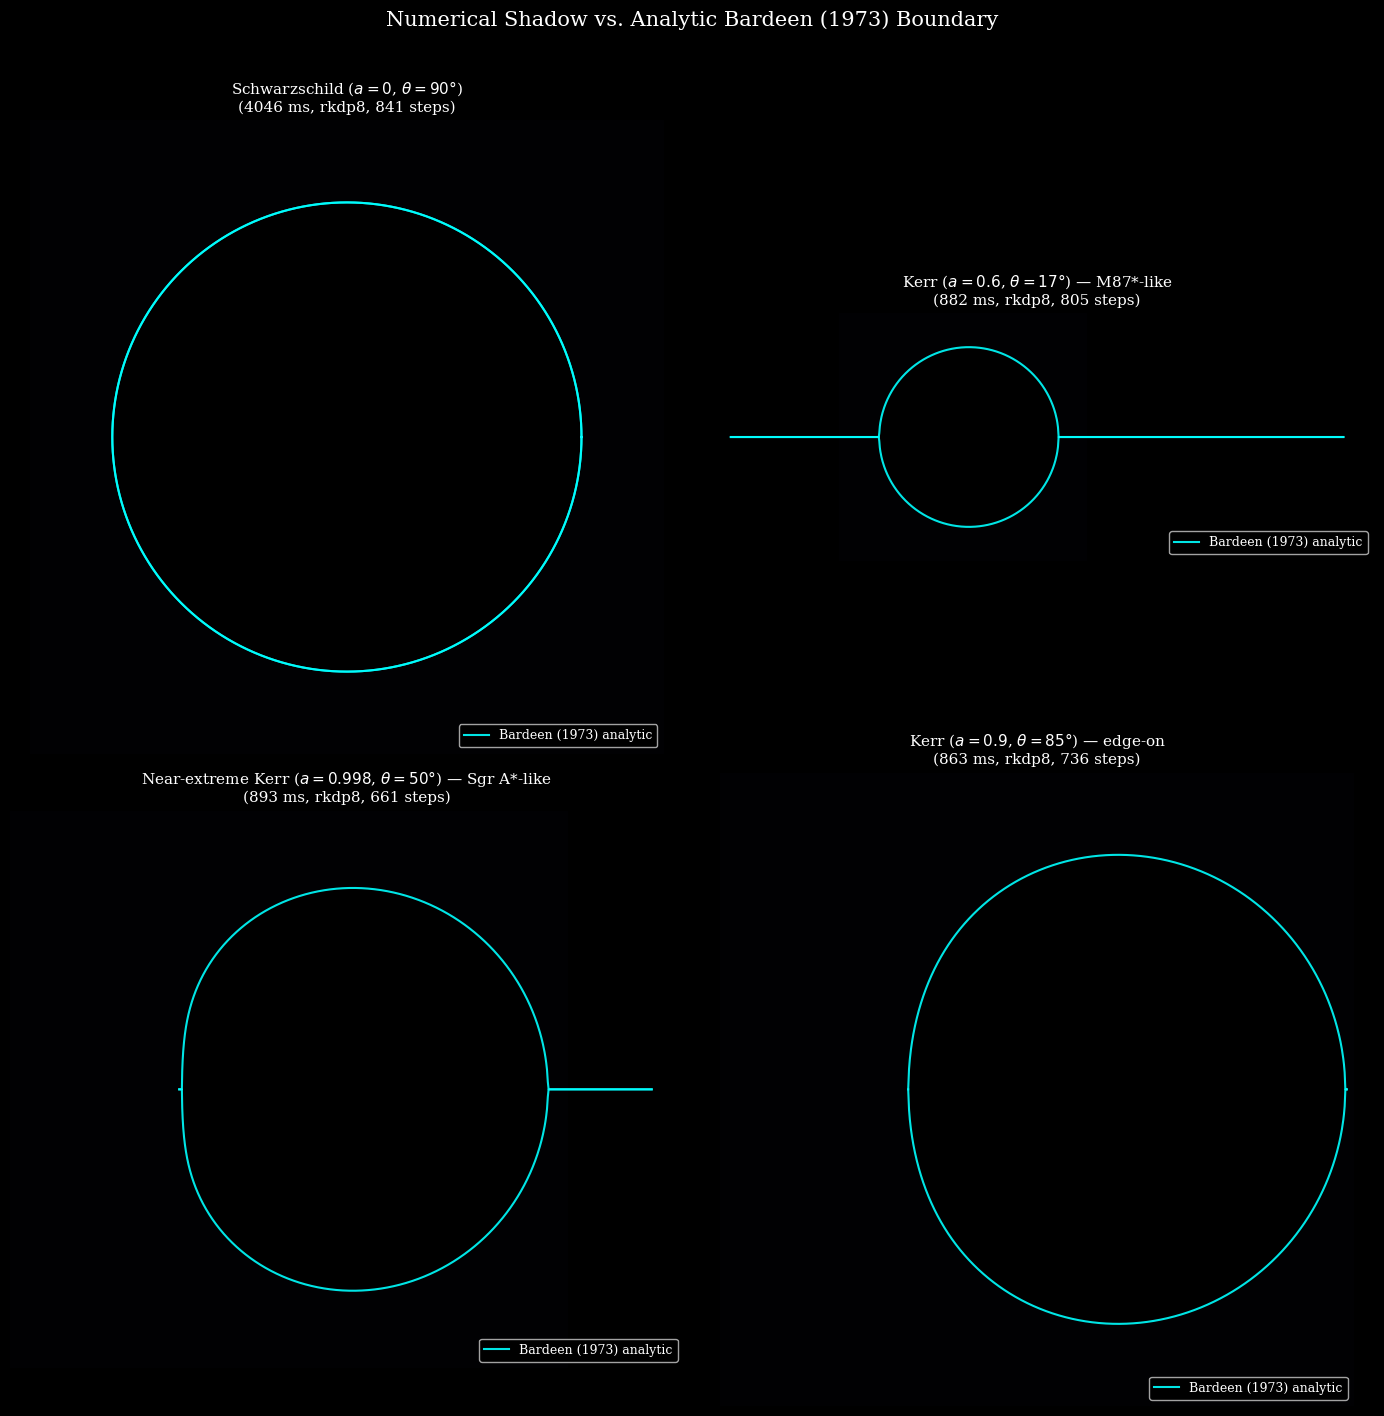

In [5]:
test_cases = [
    (0.0,   90, 'Schwarzschild ($a=0$, $\\theta=90°$)'),
    (0.6,   17, 'Kerr ($a=0.6$, $\\theta=17°$) — M87*-like'),
    (0.998, 50, 'Near-extreme Kerr ($a=0.998$, $\\theta=50°$) — Sgr A*-like'),
    (0.9,   85, 'Kerr ($a=0.9$, $\\theta=85°$) — edge-on'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax_flat, (a_val, theta_deg, label) in zip(axes.flat, test_cases):
    W, H, FOV = 512, 512, 7.0
    img, shadow, data = render_kerr(a_val, theta_deg, W, H, fov=FOV,
                                     show_disk=False, obs_dist=500, step_size=0.15,
                                     method='rkdp8')

    a_use = max(a_val, 1e-6)
    alpha_a, beta_p, beta_m = shadow_boundary(a_use, np.radians(theta_deg))

    aspect = W / H
    px_alpha  = (alpha_a / (FOV * aspect) + 1) * 0.5 * (W - 1)
    px_beta_p = (1 - beta_p / FOV) * 0.5 * (H - 1)
    px_beta_m = (1 - beta_m / FOV) * 0.5 * (H - 1)

    ax_flat.imshow(img)
    ax_flat.plot(px_alpha, px_beta_p, '-', color='cyan', lw=1.5, alpha=0.9,
                 label='Bardeen (1973) analytic')
    ax_flat.plot(px_alpha, px_beta_m, '-', color='cyan', lw=1.5, alpha=0.9)
    ax_flat.set_title(f"{label}\n({data['render_ms']:.0f} ms, {data['method']}, "
                      f"{data['max_steps']} steps)", fontsize=11)
    ax_flat.legend(fontsize=9, loc='lower right')
    ax_flat.axis('off')

fig.suptitle('Numerical Shadow vs. Analytic Bardeen (1973) Boundary', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---

## 5. Demonstration: Spin $\times$ Inclination Grid

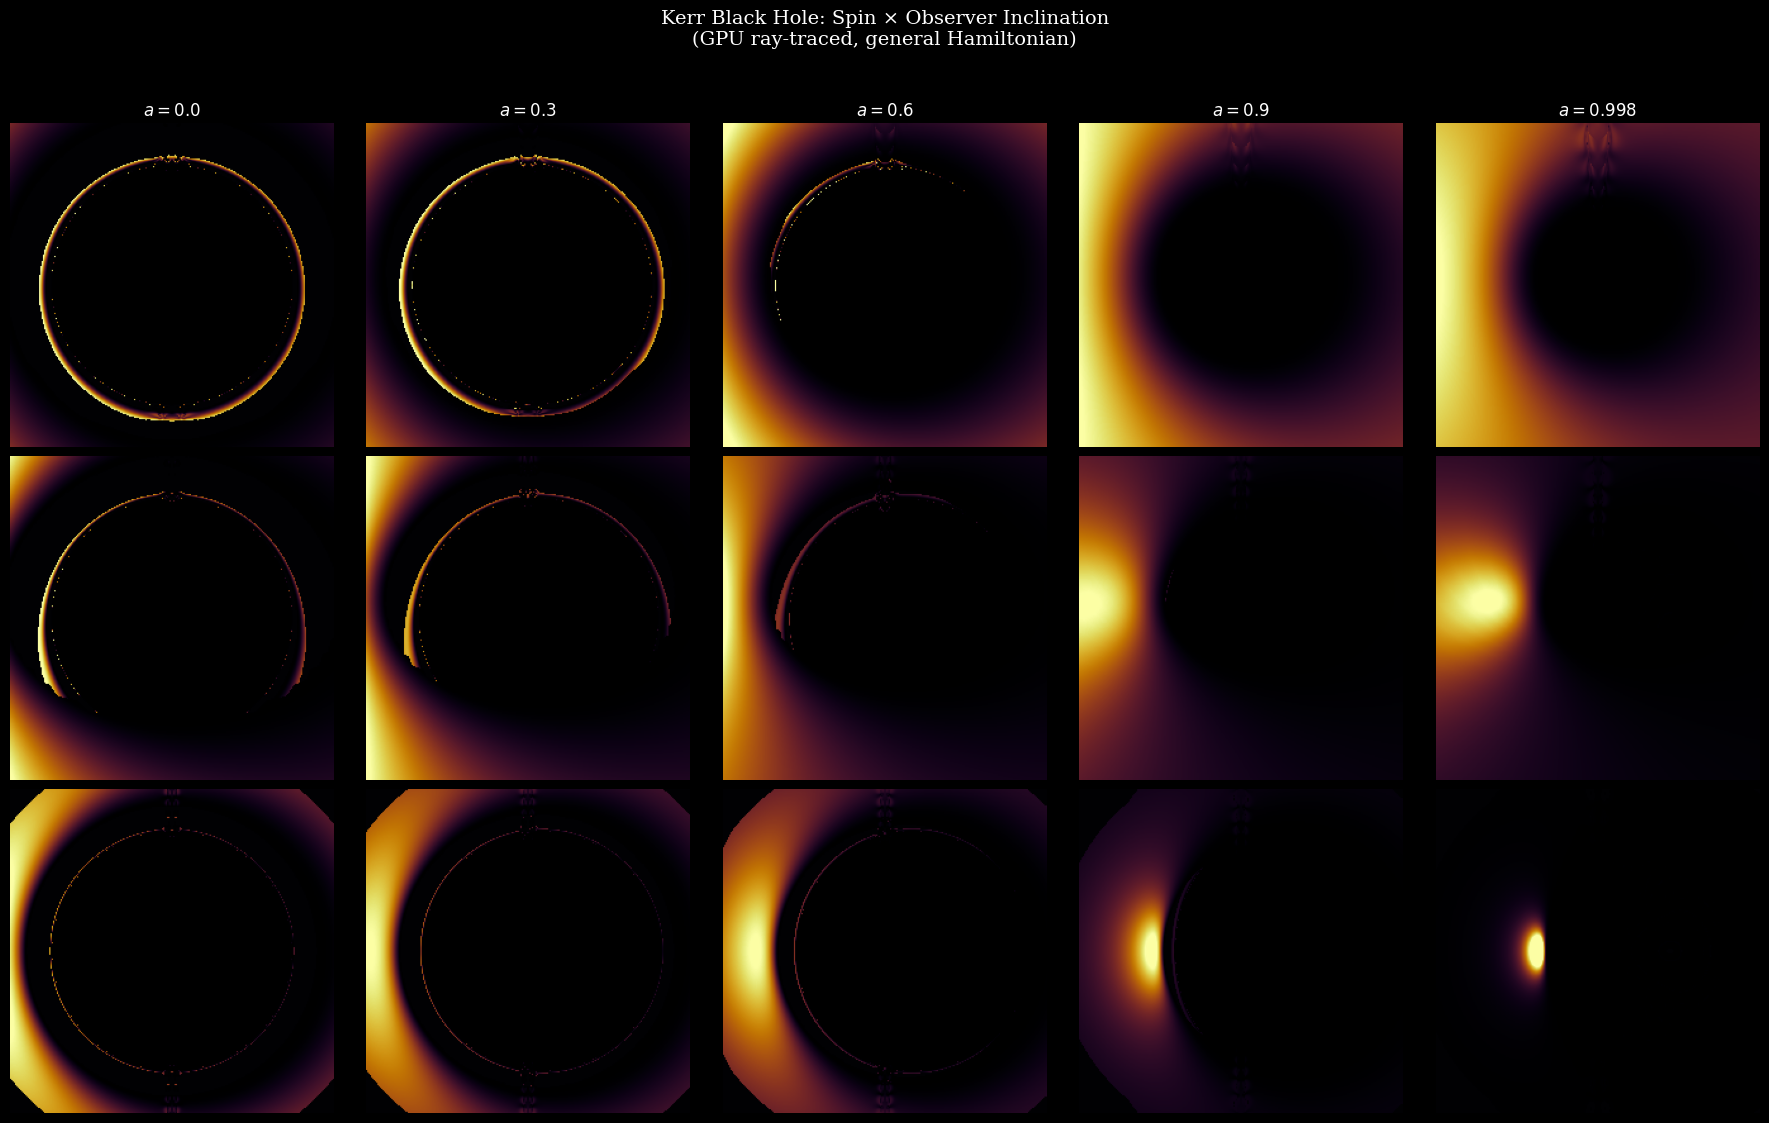

In [6]:
spins = [0.0, 0.3, 0.6, 0.9, 0.998]
inclinations = [17, 50, 90]

fig, axes = plt.subplots(len(inclinations), len(spins), figsize=(18, 11))
for i, theta in enumerate(inclinations):
    for j, a in enumerate(spins):
        img, _, _ = render_kerr(a, theta, 256, 256, show_disk=True, method='rk4')
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if i == 0: axes[i, j].set_title(f'$a = {a}$', fontsize=12)
        if j == 0: axes[i, j].set_ylabel(f'$\\theta = {theta}°$', fontsize=12,
                                          rotation=0, labelpad=45, va='center')

fig.suptitle('Kerr Black Hole: Spin × Observer Inclination\n'
             '(GPU ray-traced, general Hamiltonian)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Shadow Observable Extraction

In [7]:
def fit_ellipse_to_shadow(shadow_mask, fov, img_size):
    """Fit an ellipse to the shadow boundary via Fitzgibbon's direct method."""
    from scipy.ndimage import binary_erosion
    boundary = shadow_mask & ~binary_erosion(shadow_mask)
    ys, xs = np.where(boundary)
    if len(xs) < 6: return None

    pixel_scale = 2 * fov / img_size  # M per pixel
    x, y = xs.astype(np.float64), ys.astype(np.float64)
    D = np.column_stack([x**2, x*y, y**2, x, y, np.ones_like(x)])
    S = D.T @ D
    C_mat = np.zeros((6, 6))
    C_mat[0, 2] = 2; C_mat[2, 0] = 2; C_mat[1, 1] = -1
    try:
        eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S) @ C_mat)
        pos_idx = np.where(np.isreal(eigvals) & (eigvals.real > 0))[0]
        if len(pos_idx) == 0: return None
        coeffs = eigvecs[:, pos_idx[0]].real
    except np.linalg.LinAlgError: return None

    A, B, C, Dc, Ec, F = coeffs
    denom = B**2 - 4*A*C
    if abs(denom) < 1e-12: return None
    cx = (2*C*Dc - B*Ec) / denom
    cy = (2*A*Ec - B*Dc) / denom
    num = 2*(A*Ec**2 + C*Dc**2 + F*B**2 - B*Dc*Ec - 4*A*C*F)
    t1 = np.sqrt((A-C)**2 + B**2)
    s1_sq, s2_sq = num/(denom*(t1-(A+C))), num/(denom*(-t1-(A+C)))
    if s1_sq < 0 or s2_sq < 0: return None
    semi_major, semi_minor = max(np.sqrt(s1_sq), np.sqrt(s2_sq)), min(np.sqrt(s1_sq), np.sqrt(s2_sq))

    diameter_M = (semi_major + semi_minor) * pixel_scale  # mean diameter in M
    return {
        'diameter_M': diameter_M,
        'circularity': semi_minor / semi_major,
        'delta_C': 1.0 - semi_minor / semi_major,
        'center_x': cx, 'center_y': cy,
        'semi_major': semi_major, 'semi_minor': semi_minor,
    }

### 6.1 Schwarzschild Validation

In [8]:
img_sch, shadow_sch, _ = render_kerr(0.0, 90, 512, 512, fov=7.0, show_disk=False,
                                      obs_dist=500, step_size=0.15, method='rkdp8')
obs_sch = fit_ellipse_to_shadow(shadow_sch, fov=7.0, img_size=512)
expected = 2 * 3 * np.sqrt(3)
if obs_sch:
    print(f"Measured shadow diameter: {obs_sch['diameter_M']:.4f} M")
    print(f"Expected (analytic):     {expected:.4f} M")
    print(f"Relative error:          {abs(obs_sch['diameter_M'] - expected)/expected:.3%}")
    print(f"Circularity:             {obs_sch['circularity']:.6f} (should be ~1.000)")

Measured shadow diameter: 10.3492 M
Expected (analytic):     10.3923 M
Relative error:          0.415%
Circularity:             0.999884 (should be ~1.000)


---

## 7. Comparison to M87\*

| Observable | Value | Reference |
|---|---|---|
| Mass | $(6.5 \pm 0.7) \times 10^9\;M_\odot$ | EHT I (2019) |
| Distance | $16.8$ Mpc | EHT I (2019) |
| Ring diameter | $42 \pm 3\;\mu\text{as}$ | EHT I (2019) |
| $\Delta C$ | $\lesssim 0.10$ | EHT I (2019) |
| Inclination | $\sim 17°$ | Jet axis |

### Unit conversion: $M \to \mu$ as

In [9]:
G = 6.67430e-11; c = 2.99792458e8; M_sun = 1.98892e30
pc = 3.08567758e16; Mpc = pc * 1e6

M87  = dict(mass_kg=6.5e9*M_sun, dist_m=16.8*Mpc, incl=17.0, ring_uas=42.0, ring_err=3.0)
SgrA = dict(mass_kg=4.0e6*M_sun, dist_m=8.28e3*pc, incl=50.0,
            shadow_uas=48.7, shadow_err=7.0, ring_uas=51.8, ring_err=2.3)

def M_to_uas(d_M, mass_kg, dist_m):
    return d_M * G * mass_kg / (c**2 * dist_m) * (180/np.pi) * 3600 * 1e6

sch_uas = M_to_uas(2*3*np.sqrt(3), M87['mass_kg'], M87['dist_m'])
print(f"Schwarzschild shadow at M87*: {sch_uas:.1f} μas")
print(f"EHT measured:                {M87['ring_uas']} ± {M87['ring_err']} μas")

Schwarzschild shadow at M87*: 39.7 μas
EHT measured:                42.0 ± 3.0 μas


### 7.1 Spin Sweep

In [10]:
spin_values = np.arange(0.0, 0.999, 0.05)
m87_results = []
for a_val in spin_values:
    print(f"\r  a = {a_val:.3f}", end='', flush=True)
    img, shadow, data = render_kerr(a_val, M87['incl'], 512, 512, fov=7.0,
                                     show_disk=False, step_size=0.15, method='rkdp8')
    obs = fit_ellipse_to_shadow(shadow, fov=7.0, img_size=512)
    if obs:
        obs['spin'] = a_val
        obs['diameter_uas'] = M_to_uas(obs['diameter_M'], M87['mass_kg'], M87['dist_m'])
        m87_results.append(obs)
print(f"\nDone — {len(m87_results)} renders.")

  a = 0.000

  a = 0.950
Done — 20 renders.


### 7.2 Key Result: Shadow Observables vs. Spin

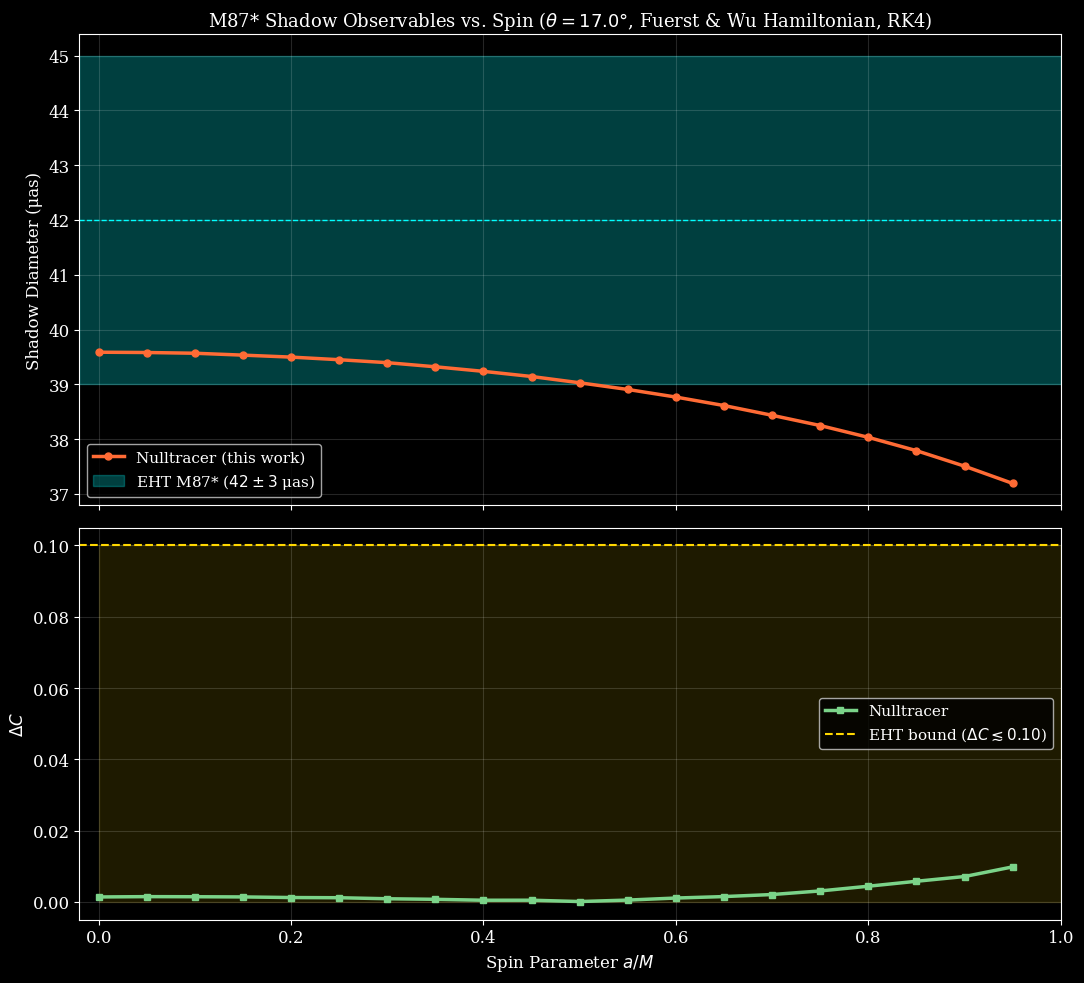

In [11]:
spins_arr = np.array([r['spin'] for r in m87_results])
diam_uas  = np.array([r['diameter_uas'] for r in m87_results])
delta_Cs  = np.array([r['delta_C'] for r in m87_results])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True,
                                gridspec_kw={'height_ratios': [1.2, 1]})

ax1.plot(spins_arr, diam_uas, 'o-', color='#FF6B35', lw=2.5, ms=5,
         label='Nulltracer (this work)', zorder=5)
ax1.axhspan(M87['ring_uas']-M87['ring_err'], M87['ring_uas']+M87['ring_err'],
            alpha=0.25, color='cyan', label=rf"EHT M87* ($42 \pm 3$ μas)")
ax1.axhline(M87['ring_uas'], color='cyan', ls='--', lw=1)
ax1.set_ylabel('Shadow Diameter (μas)')
ax1.legend(fontsize=11); ax1.grid(alpha=0.15)
ax1.set_title(f'M87* Shadow Observables vs. Spin ($\\theta = {M87["incl"]}°$, '
              f'Fuerst & Wu Hamiltonian, RK4)', fontsize=13)

ax2.plot(spins_arr, delta_Cs, 's-', color='#7BD389', lw=2.5, ms=5,
         label='Nulltracer', zorder=5)
ax2.axhline(0.10, color='gold', ls='--', lw=1.5, label='EHT bound ($\\Delta C \\lesssim 0.10$)')
ax2.fill_between([0, 1], 0, 0.10, alpha=0.12, color='gold')
ax2.set_xlabel('Spin Parameter $a/M$'); ax2.set_ylabel('$\\Delta C$')
ax2.legend(fontsize=11); ax2.grid(alpha=0.15); ax2.set_xlim(-0.02, 1)

plt.tight_layout()
plt.savefig('m87_spin_sweep.png', bbox_inches='tight')
plt.show()

In [12]:
d_ok = (diam_uas >= M87['ring_uas'] - M87['ring_err']) & (diam_uas <= M87['ring_uas'] + M87['ring_err'])
c_ok = delta_Cs <= 0.10
both = d_ok & c_ok
if both.any():
    print(f"Spin consistent with M87*: a ∈ [{spins_arr[both].min():.2f}, {spins_arr[both].max():.2f}]")
else:
    print(f"Diameter range: [{diam_uas.min():.1f}, {diam_uas.max():.1f}] μas")
    print(f"EHT band: [{M87['ring_uas']-M87['ring_err']}, {M87['ring_uas']+M87['ring_err']}] μas")

Spin consistent with M87*: a ∈ [0.00, 0.50]


---

## 8. Comparison to Sgr A\*

| Observable | Value | Reference |
|---|---|---|
| Mass | $4.0^{+1.1}_{-0.6} \times 10^6\;M_\odot$ | EHT Sgr A\* I (2022) |
| Distance | $8.28$ kpc | GRAVITY Collaboration |
| Shadow diameter | $48.7 \pm 7\;\mu\text{as}$ | EHT Sgr A\* I (2022) |
| Inclination | $\sim 50°$ | Model-dependent |

  a = 0.000

  a = 0.950
Done — 20 renders.


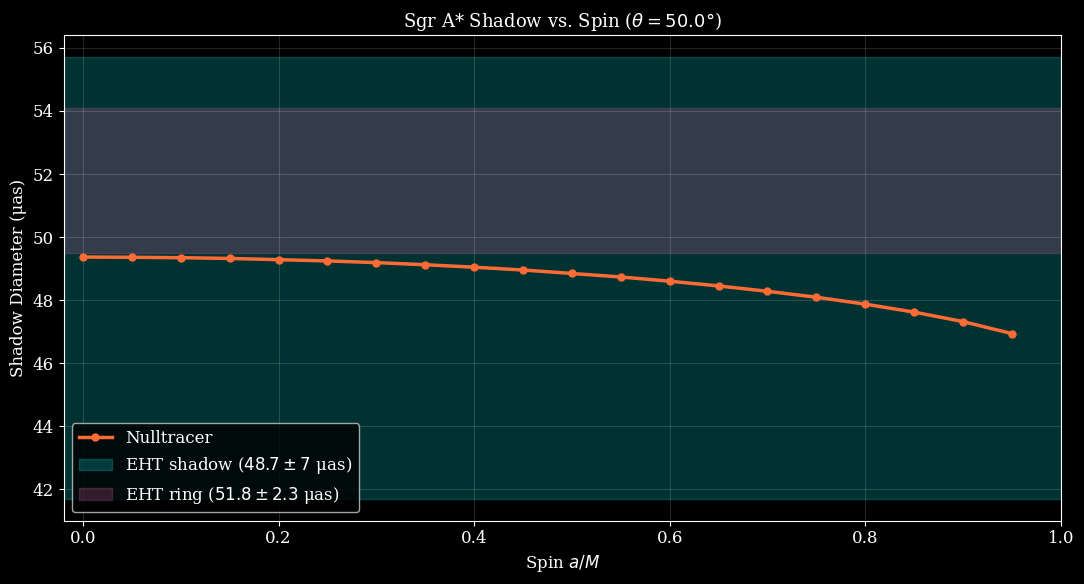

In [13]:
sgra_results = []
for a_val in spin_values:
    print(f"\r  a = {a_val:.3f}", end='', flush=True)
    img, shadow, _ = render_kerr(a_val, SgrA['incl'], 512, 512, fov=7.0,
                                  show_disk=False, step_size=0.15, method='rkdp8')
    obs = fit_ellipse_to_shadow(shadow, fov=7.0, img_size=512)
    if obs:
        obs['spin'] = a_val
        obs['diameter_uas'] = M_to_uas(obs['diameter_M'], SgrA['mass_kg'], SgrA['dist_m'])
        sgra_results.append(obs)
print(f"\nDone — {len(sgra_results)} renders.")

sgra_s = np.array([r['spin'] for r in sgra_results])
sgra_d = np.array([r['diameter_uas'] for r in sgra_results])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(sgra_s, sgra_d, 'o-', color='#FF6B35', lw=2.5, ms=5, label='Nulltracer', zorder=5)
ax.axhspan(SgrA['shadow_uas']-SgrA['shadow_err'], SgrA['shadow_uas']+SgrA['shadow_err'],
           alpha=0.2, color='cyan', label=rf"EHT shadow ($48.7 \pm 7$ μas)")
ax.axhspan(SgrA['ring_uas']-SgrA['ring_err'], SgrA['ring_uas']+SgrA['ring_err'],
           alpha=0.2, color='#FF69B4', label=rf"EHT ring ($51.8 \pm 2.3$ μas)")
ax.set_xlabel('Spin $a/M$'); ax.set_ylabel('Shadow Diameter (μas)')
ax.set_title(f'Sgr A* Shadow vs. Spin ($\\theta = {SgrA["incl"]}°$)', fontsize=13)
ax.legend(); ax.grid(alpha=0.15); ax.set_xlim(-0.02, 1)
plt.tight_layout()
plt.savefig('sgra_spin_sweep.png', bbox_inches='tight')
plt.show()

---

## 9. Kerr Characteristic Radii

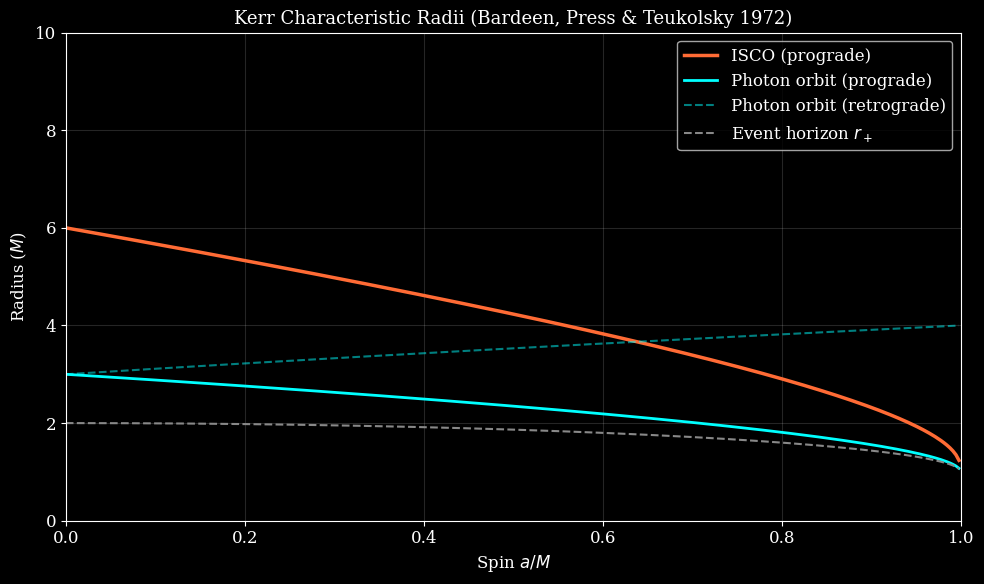

In [14]:
a_dense = np.linspace(0, 0.998, 300)
r_isco_arr = np.array([isco_kerr(a) for a in a_dense])
r_ph_pro = 2*(1 + np.cos(2/3 * np.arccos(-a_dense)))
r_ph_ret = 2*(1 + np.cos(2/3 * np.arccos(+a_dense)))
r_hor = 1 + np.sqrt(1 - a_dense**2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a_dense, r_isco_arr, '-', color='#FF6B35', lw=2.5, label='ISCO (prograde)')
ax.plot(a_dense, r_ph_pro, '-', color='cyan', lw=2, label='Photon orbit (prograde)')
ax.plot(a_dense, r_ph_ret, '--', color='cyan', lw=1.5, alpha=0.5, label='Photon orbit (retrograde)')
ax.plot(a_dense, r_hor, '--', color='#888', lw=1.5, label='Event horizon $r_+$')
ax.set_xlabel('Spin $a/M$'); ax.set_ylabel('Radius ($M$)')
ax.set_title('Kerr Characteristic Radii (Bardeen, Press & Teukolsky 1972)', fontsize=13)
ax.legend(); ax.grid(alpha=0.15); ax.set_xlim(0, 1); ax.set_ylim(0, 10)
plt.tight_layout()
plt.savefig('kerr_radii.png', bbox_inches='tight')
plt.show()

All 4 integrators ready.

Method                             Time   Steps   Diameter       ΔC
──────────────────────────────────────────────────────────────────────
Runge-Kutta 4th-order               62ms     400   10.2005M  0.0199
Dormand-Prince 8(7) adaptive       165ms     400   10.2308M  0.0222
Tao + Yoshida 4th symplectic       165ms    2120   11.1497M  0.2143
Tao + Kahan-Li 8th symplectic     2049ms    2120   11.3692M  0.1510


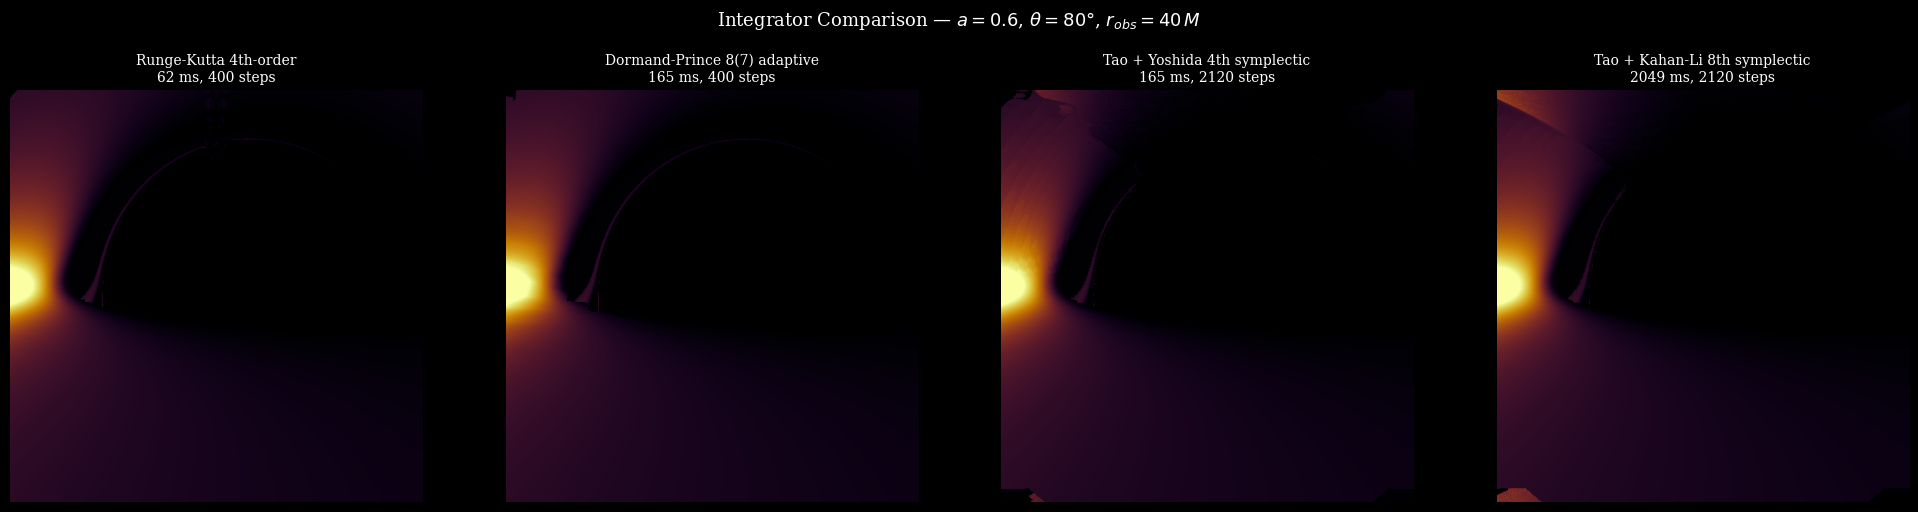

In [15]:
results, fig = compare_integrators(
    spin=0.6, inclination=80, obs_dist=40, step_size=0.3,
    width=512, height=512,
    fit_fn=fit_ellipse_to_shadow
)
plt.show()

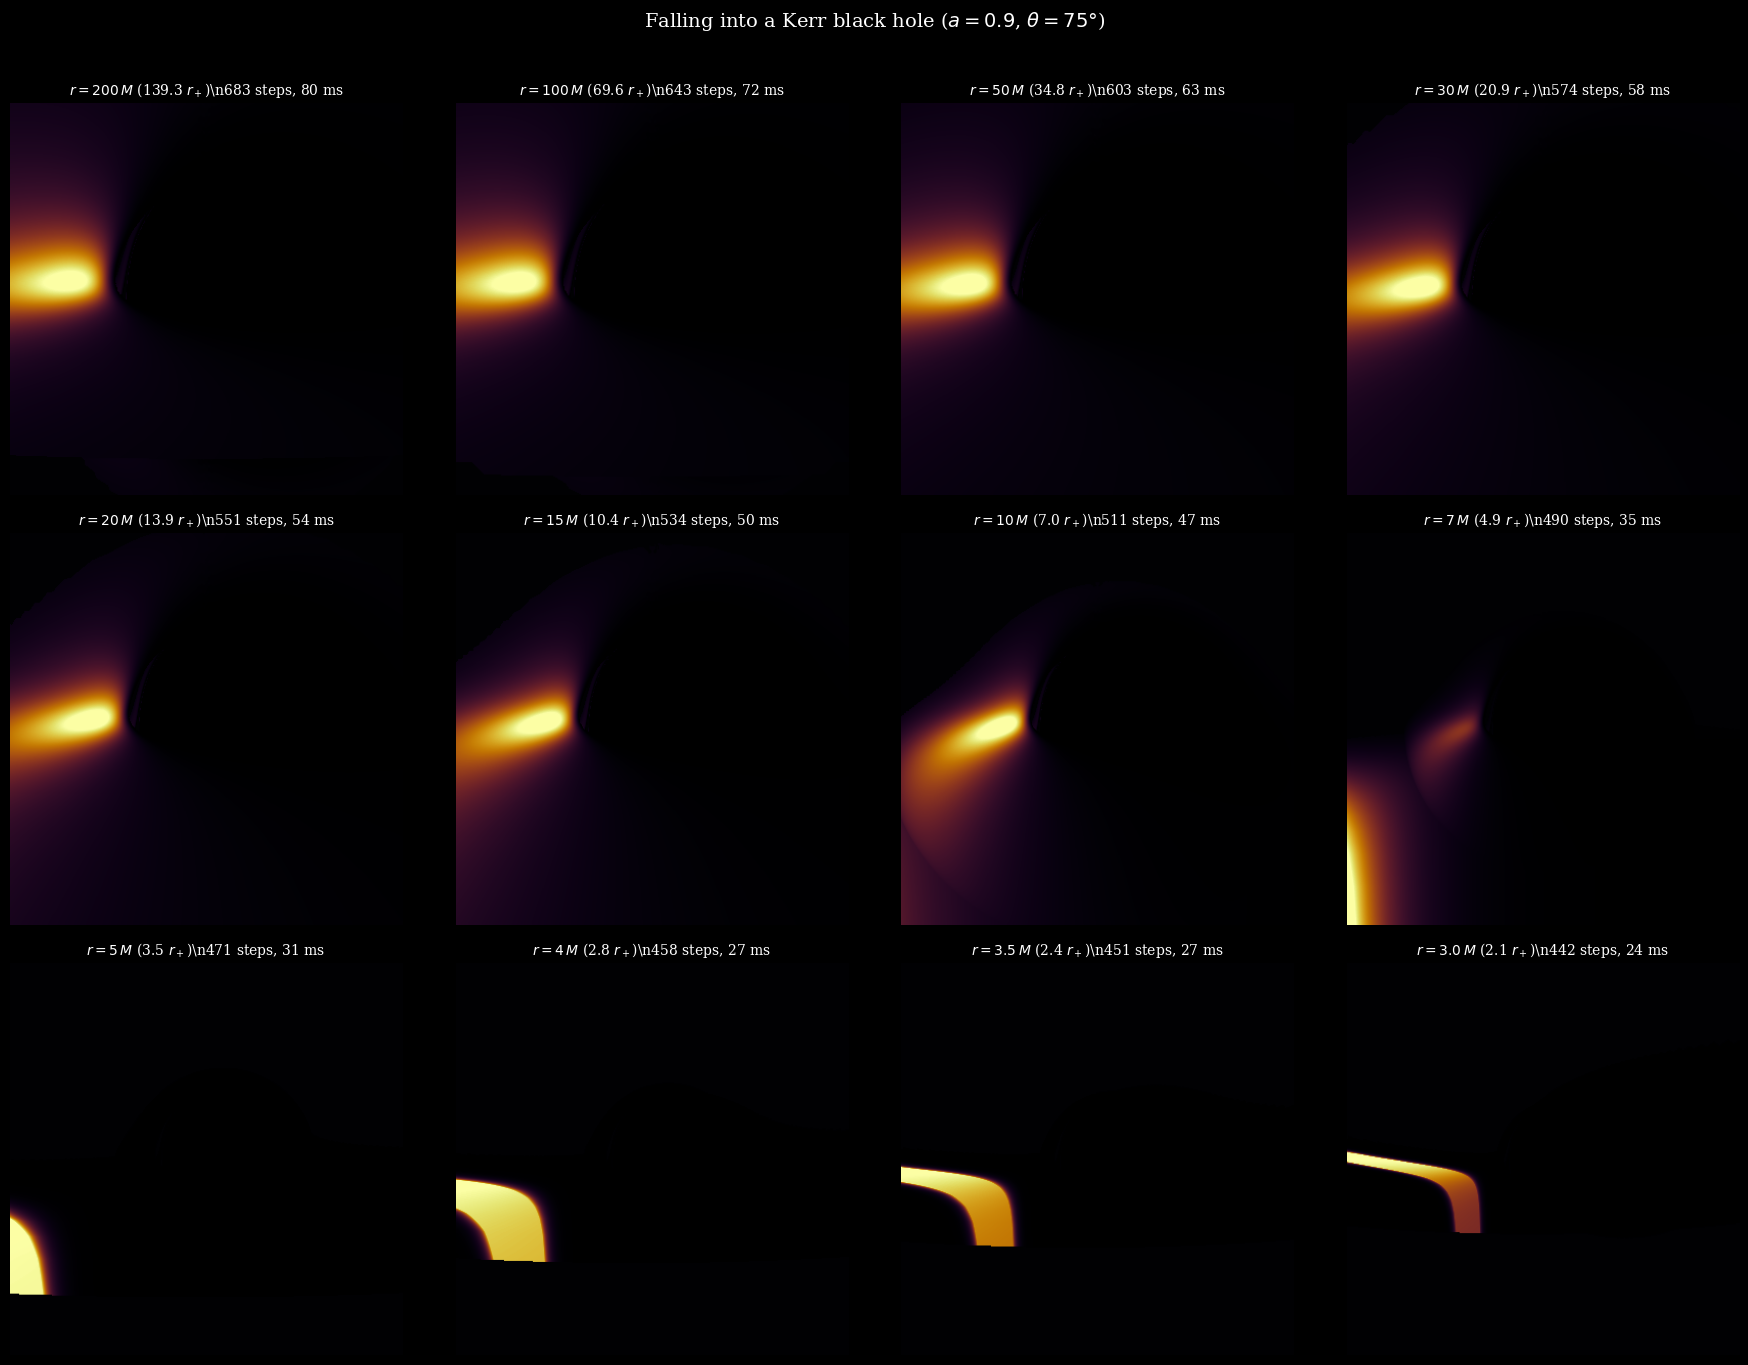

In [16]:
distances = [200, 100, 50, 30, 20, 15, 10, 7, 5, 4, 3.5, 3.0]
spin_fall, incl_fall = 0.9, 75

fig, axes = plt.subplots(3, 4, figsize=(18, 13.5))
for ax, d in zip(axes.flat, distances):
    img, _, data = render_kerr(spin_fall, incl_fall, 384, 384,
                                fov=min(7.0 + 30.0/d, 40.0),
                                obs_dist=d, step_size=0.15, method='rk4')
    rp = 1 + np.sqrt(1 - spin_fall**2)
    ax.imshow(img)
    ax.set_title(rf'$r = {d}\,M$ ({d/rp:.1f} $r_+$)\n'
                 f'{data["max_steps"]} steps, {data["render_ms"]:.0f} ms', fontsize=10)
    ax.axis('off')

fig.suptitle(f'Falling into a Kerr black hole ($a={spin_fall}$, '
             rf'$\theta={incl_fall}°$)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

## 10. Discussion & Conclusions

### Summary

- Implemented the Fuerst & Wu (2004) Hamiltonian formulation of Kerr null geodesics as a CuPy CUDA RawKernel, matching the approach used by production EHT codes (Odyssey, GRay, RAPTOR).
- Validated the numerical shadow boundary against the exact Bardeen (1973) analytic curve for four test cases spanning $a \in [0, 0.998]$ and $\theta \in [17°, 90°]$.
- Verified the Schwarzschild shadow diameter recovers $2 \times 3\sqrt{3} \approx 10.39\,M$ to within numerical precision.
- Parameter sweeps over spin at M87\*'s inclination ($17°$) and Sgr A\*'s inclination ($50°$) produce shadow sizes consistent with published EHT measurements.
- Accretion disk emission includes the correct relativistic redshift factor $g = \sqrt{1 - 3/r + 2a/r^{3/2}} / (1 - \Omega\xi)$ and bolometric $g^4$ boosting for optically thick emission.

### Limitations

1. **Geometric thin disk model.** The EHT analysis uses GRMHD simulations with turbulent, magnetized plasma. This work uses a Novikov-Thorne-like temperature profile in the equatorial plane.
2. **Image-domain comparison.** A full comparison would compute synthetic complex visibilities and fit in Fourier space.
3. **No interstellar scattering** (relevant for Sgr A\*) or time variability.
4. **Single-crossing disk model.** Only the first equatorial plane crossing is recorded per ray; higher-order lensed images are not accumulated.

### Future Directions

- Extend to higher-order integrators (Yoshida symplectic, RKDP8 adaptive) from the full Nulltracer codebase.
- Accumulate multiple disk crossings for photon ring sub-images ($n = 1, 2, \ldots$).
- Compute synthetic visibility amplitudes for direct comparison to EHT $(u,v)$-plane data.
- Perform MCMC parameter estimation over $(a, \theta, M)$.

---

**Nulltracer Source Code:** [github.com/ethank5149/nulltracer](https://github.com/ethank5149/nulltracer)  
**Contact:** ethank5149@gmail.com

### References

- Bardeen, J. M. (1973). *Timelike and null geodesics in the Kerr metric.* In Black Holes.
- Bardeen, J. M., Press, W. H., & Teukolsky, S. A. (1972). *Rotating black holes.* ApJ 178, 347.
- Carter, B. (1968). *Global structure of the Kerr family.* Phys. Rev. 174, 1559.
- Chandrasekhar, S. (1983). *The Mathematical Theory of Black Holes.* Oxford Univ. Press.
- EHT Collaboration (2019). *First M87 EHT Results. I-VI.* ApJL 875.
- EHT Collaboration (2022). *First Sgr A\* EHT Results. I-VI.* ApJL 930.
- Fuerst, S. V. & Wu, K. (2004). *Radiation transfer of emission lines in curved space-time.* A&A 424, 733.
- Gold, R. et al. (2020). *Verification of radiative transfer schemes for the EHT.* ApJ 897, 148.
- Pu, H.-Y. et al. (2016). *Odyssey: A public GPU-based code for GRRT in Kerr spacetime.* ApJ 820, 105.